# **Μερική Διαφορική Εξίσωση (μη-γραμμική) Complex Ginzburg - Landau (1971) 1D**

### **Προσεγγίζουμε την ΜΔΕ CGL:**

$$
A_t = A + (1+i\ α) A_{xx} - (1+i\ β)\ |A|^2\ A
$$

$$ α=β\ \text{ έχουμε την NLS} $$
$$ 1+αβ > 0\ \text{  το σύστυμα σταθερό}$$
$$ 1+αβ < 0\ \text{  το σύστυμα ασταθές} $$

---

**με**

$$x \in \left[-\frac{L}{2},\frac{L}{2}\right]=[-20,20]$$

$$t \in [0,T]=[0,5]$$

$$α=1 $$
$$β=-0.5 $$

---
### **Λυση

$$
A(x,t)=A_0 sech( (x-vt)/w ) e^{[i(kx−ωt+φ_0)]},
$$
### **Αρχική συνθήκη:**

$$
A(x,0) = Α_0\ sech( A_0\ (x - x_0))\ e^{i\ (c\ x + φ_0)}
$$

**με**

$$
A_0^2 = \frac{1}{1+β^2}
$$

$$
x_0 = 0
$$

$$
c=0.5
$$

$$
φ_0 = 0
$$
---

### **Συνοριακές συνθήκες: (Περιοδικές)**

$$
A\left(-\frac{L}{2},t\right)=A\left(\frac{L}{2},t\right)
$$
$$
A_x\left(-\frac{L}{2},t\right)=A_x\left(\frac{L}{2},t\right)
$$

---

### *Πραγματοποιούμε χωρισμό πραγματικού και φανταστικού μέρους:*

$$ A = u + i\ v $$

###*τότε για την NLS:*
$$
\text{Πραγματικό μέρος: } Α_{re} =
u_t - u - u_{xx} + α\ v_{xx} + (u - β\ v)(u^2 + v^2) = 0
$$

$$
\text{Φανταστικό μέρος: } Α_{im} =
v_t - v - v_{xx} + α\ u_{xx} + (v + β\ u)(u^2 + v^2) = 0
$$

---
$$$$
$$e^{ix} = cos(x) + i\ sin(x)$$

###*τότε για την Αρχική Συνθήκη*

$$
\text{Πραγματικό μέρος: } Α_{re}(x,0) = Α_0\ sech( \frac{x - x_0}{ω})\ cos(k\ x + φ_0)
$$

$$
\text{Φανταστικό μέρος: } Α_{im}(x,0) = Α_0\ sech( \frac{x - x_0}{ω})\ sin(k\ x + φ_0)
$$

In [374]:
import torch #βασικό πακέτο PyTorch
import torch.nn as nn #έτοιμες συναρτήσεις για νν
import torch.nn.functional as f #συναρτήσεις ενεργοποίησης
import torch.optim as optim #βελτιστοποιητές
import numpy as np #βιβλιοθήκη αριθμητικών υπολογισμών
from time import time #μέτρηση χρόνου

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(torch.__version__)
print(torch.cuda.is_available())

2.8.0+cu126
False


In [375]:
#ορισμός ακρίβειας
dtype = torch.float32

#Σταθερές
pi = torch.tensor(np.pi, dtype=dtype, device=device) #π
a = torch.tensor(1.0, dtype=dtype, device=device)
b = torch.tensor(0.5, dtype=dtype, device=device)

A_zero = torch.sqrt(1/(1+b**2)) #πλάτος σολιτονίου
x_zero = torch.tensor(0, dtype=dtype, device=device) #αρχική μετατόπιση
c = torch.tensor(0.5, dtype=dtype, device=device) #κυματάριθμος
#omega = b + (a - b) * c**2 #συχνότητα
omega = torch.sqrt(2 * (1 + a * b) / (1 + b**2)) #συχνότητα
phi_zero = torch.tensor(0, dtype=dtype, device=device) #αρχική φάση
v_sp = 2 * c * torch.abs(a - b) #ταχύτητα του σολιτονίου
kappa = torch.sqrt(1 - (1 + a*b) * c**2)

L=40 #συνολικό πλάτος χώρου
L_min = torch.tensor(-L/2, dtype=dtype, device=device) #πλάτος χώρου ελάχιστο
L_max = torch.tensor(L/2, dtype=dtype, device=device) #πλάτος χώρου μεγιστο
T_max = torch.tensor(5, dtype=dtype, device=device) #χρόνος

#Αρχική Συνθήκη
def fun_psi_0(t,x):
    #Χωρισμός πραγματικού και φανταστικού μέρους
    #Κατασκευή δύο καναλιών
    temp1 = A_zero * (x - x_zero)
    temp2 = c * x + phi_zero

    u_0 = A_zero / torch.cosh(temp1) * torch.cos(temp2)   #πραγματικό μέρος
    v_0 = A_zero / torch.cosh(temp1) * torch.sin(temp2)   #φανταστικό μέρος
    return u_0, v_0

#Συνοριακές Συνθήκες
def fun_psi_b_left(t,x):
    #Στις περιοδικές δεν έχω αντίστοιχη συνάρτηση
    #Ενσωματώνονται στο training loop και loss
    return None

def fun_psi_b_right(t,x):
    #Στις περιοδικές δεν έχω αντίστοιχη συνάρτηση
    #Ενσωματώνονται στο training loop και loss
    return None

#ΜΔΕ Εξίσωση NLS
def fun_r(u, v, u_t, v_t, u_xx, v_xx):
    res_re = u_t - u - u_xx + a * v_xx + (u - b * v) * (u**2 + v**2) #πραγματικό μέρος
    res_im = v_t - v - v_xx + a * u_xx + (v + b * u) * (u**2 + v**2)  #φανταστικό μέρος
    return res_re, res_im

In [376]:
#Χαρακτηριστικά CGL

print("----------------------------\n")
print("Παράμετροι CGL:\n")
print(f'a = {a}, b = {b}, k = {k}, x_0 = {x_zero}, φ_0 = {phi_zero}')
print(f'A_0 = {A_zero.item():+.4f}')
print(f'ω = {omega.item():+.4f}')
print(f'1+αβ = {(1+a*b).item():+.4f}')
print("\n----------------------------\n")

print("Χαρακτηριστικά CGL:\n")

if (1+a*b).item() > 0:
  print("Το σύστημα είναι σταθερό. Εμφανίζονται ομαλά κύματα.")
elif (1+a*b).item() < 0:
  print("Το σύστημα είναι ασταθές. Δημιουργούνται χαοτικά μοτίβα.")
else:
  print('Το σύστημα ειναι συντηρητικό. Έχουμε την NLS.')

print("\n----------------------------")


----------------------------

Παράμετροι CGL:

a = 1.0, b = 0.5, k = 0.0, x_0 = 0.0, φ_0 = 0.0
A_0 = +0.8944
ω = +1.5492
1+αβ = +1.5000

----------------------------

Χαρακτηριστικά CGL:

Το σύστημα είναι σταθερό. Εμφανίζονται ομαλά κύματα.

----------------------------


In [377]:
#Αριθμός σημείων
N_0 = 500 #πλήθος αρχικής συνθήκες u(x,0)
N_b = 700 #πλήθος συνοριακών συνθηκών u(±L, t)
N_r = 1000 #πλήθος στο εσωτερικό του πεδίου εκπαίδευσης της ΜΔΕ

#Συνοριακές τιμές
tmin = torch.tensor(0, dtype=dtype, device=device)
tmax = T_max
xmin = L_min
xmax = L_max

In [378]:
print(f'Τα όρια του χωροχρονικού πεδίου σε μορφή tensor:\n')
print(f'[tmin,tmax] x [xmin,xmax]')
print(f'[{tmin}, {tmax.item()}] x [{xmin.item()}, {xmax.item()}]\n')

Τα όρια του χωροχρονικού πεδίου σε μορφή tensor:

[tmin,tmax] x [xmin,xmax]
[0.0, 5.0] x [-20.0, 20.0]



In [379]:
#Κάτω όριο
lb = torch.tensor([tmin, xmin], dtype=dtype, device=device)
#Πάνω όριο
ub = torch.tensor([tmax, xmax], dtype=dtype, device=device)

In [380]:
#Σταθεροποίηση γεννήτριας τυχαίων αριθμών
torch.manual_seed(0)

In [381]:
#Δημιουργία σημείων αρχικών συνθηκών


#στήλη με την αρχική τιμή του χρόνου
t_0 = torch.ones((N_0,1), dtype=dtype, requires_grad=True, device=device)*lb[0]

#στήλη με τυχαίους στο διάστημα [xmin,xmax]
x_0 = torch.rand((N_0,1), dtype=dtype, requires_grad=True, device=device)*(ub[1]-lb[1]) + lb[1]

#Συνδιασμός σε tensor (N0,2) ##δύο στήλες t0,x0
X_0 = torch.concat([t_0, x_0], dim=1)

In [382]:
print(f't_0: ',t_0.shape)
print(f'x_0: ',x_0.shape)
print(f'X_0: ',X_0.shape)

t_0:  torch.Size([500, 1])
x_0:  torch.Size([500, 1])
X_0:  torch.Size([500, 2])


In [383]:
#Υπολογισμός αρχικής συνθήκης
u_0, v_0 = fun_psi_0(t_0, x_0)

In [384]:
print(f'u_0: ',u_0.shape)
print(f'v_0: ',v_0.shape)

u_0:  torch.Size([500, 1])
v_0:  torch.Size([500, 1])


In [385]:
# Δημιουργία σημείων συνοριακών συνθηκών


#στήλη με τυχαίους στο διάστημα [tmin, tmax]
t_b = torch.rand((N_b,1), dtype=dtype, requires_grad=True, device=device)*(ub[0]-lb[0]) + lb[0]

#στήλη με N_b στοιχεία για το xmin σύνορο (αριστερά)
x_b_left = torch.ones((N_b, 1), dtype=dtype, requires_grad=True, device=device)*lb[1]

#στήλη με N_b στοιχεία για το xmax σύνορο (δεξιά)
x_b_right = torch.ones((N_b, 1), dtype=dtype, requires_grad=True, device=device)*ub[1]

#Συνδιασμός σε tensor (N_b,3)
X_b = torch.concat([t_b, x_b_left, x_b_right], dim=1)

In [386]:
print(f't_b: ',t_b.shape)
print(f'x_b_left: ',x_b_left.shape)
print(f'x_b_right: ',x_b_right.shape)
print(f'X_b: ',X_b.shape)

t_b:  torch.Size([700, 1])
x_b_left:  torch.Size([700, 1])
x_b_right:  torch.Size([700, 1])
X_b:  torch.Size([700, 3])


In [387]:
#Υπολογισμός Συνοριακών Συνθηκών

#Αυτό το κομμάτι κώδικα στις περιοδικές δεν χρειάζεται.
#Δεν έχουμε να υπολογίσουμε κάτι, θέλουμε απλά να είναι ίσες.

In [388]:
#Τυχαία σημεία λύσης

#Δημιουργία τυχαίων τιμών στο χρόνο [tmin, tmax]
t_r = torch.rand((N_r,1), dtype=dtype, requires_grad=True, device=device)*(ub[0]-lb[0]) + lb[0]

#Δημιουργία τυχαίων τιμών στο χώρο [xmin, xmax]
x_r = torch.rand((N_r,1), dtype=dtype, requires_grad=True, device=device)*(ub[1]-lb[1]) + lb[1]

#Συνδιασμός σημείων σε tensor (N_r,2)
X_r = torch.concat([t_r, x_r], dim=1)

In [389]:
print(f't_r: ', t_r.shape)
print(f'x_r: ',x_r.shape)
print(f'X_r: ',X_r.shape)

t_r:  torch.Size([1000, 1])
x_r:  torch.Size([1000, 1])
X_r:  torch.Size([1000, 2])


In [390]:
#λίστες

#(Ν_0,2) αρχικά σημεία, (Ν_b,3) συνοριακά σημεία
X_data = [X_0, X_b]

#(Ν_0,2) αρχικές τιμές
psi_data = [u_0, v_0]

In [391]:
print(f'X_0: ',X_data[0].shape)
print(f'X_b: ',X_data[1].shape)
print(f'u_0: ',psi_data[0].shape)
print(f'v_0: ',psi_data[0].shape)

X_0:  torch.Size([500, 2])
X_b:  torch.Size([700, 3])
u_0:  torch.Size([500, 1])
v_0:  torch.Size([500, 1])


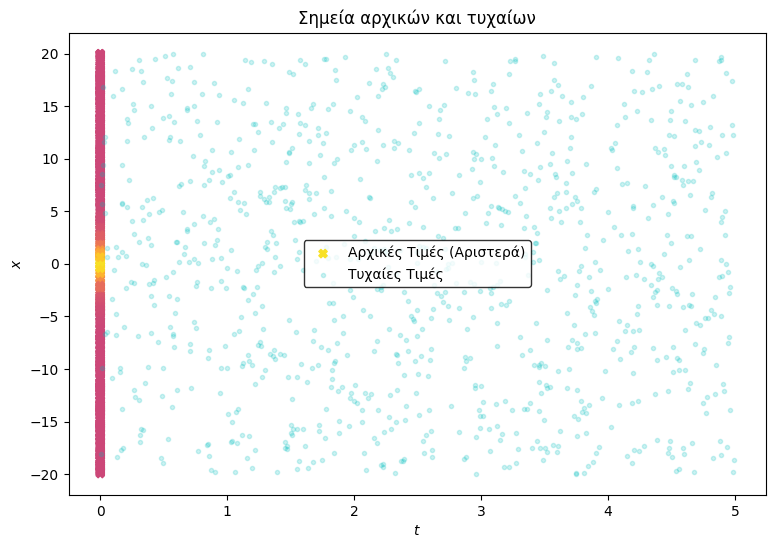

In [392]:
import matplotlib.pyplot as plt #βιβλιοθήκη γραφήματα

fig = plt.figure(figsize=(9,6)) #καμβάς 9x6 ίντσες
color = 'plasma' #επιλογή χρώματος γραφίματος

psi0_abs = torch.sqrt(u_0**2 + v_0**2) #μέτρο κυματοσυνάρτησης

#σημεία αρχικής συνθήκης
plt.scatter(t_0.cpu().detach(), x_0.cpu().detach(), c=psi0_abs.cpu().detach(), marker='X', vmin=-1, vmax=1, cmap=color, label='Αρχικές Τιμές (Αριστερά)')

#σημεία τυχαία
plt.scatter(t_r.cpu().detach(), x_r.cpu().detach(), c='c', marker='.', alpha=0.2, label='Τυχαίες Τιμές')

plt.xlabel('$t$')
plt.ylabel('$x$')
plt.legend(loc='center').get_frame().set_edgecolor('black')
plt.title('Σημεία αρχικών και τυχαίων');

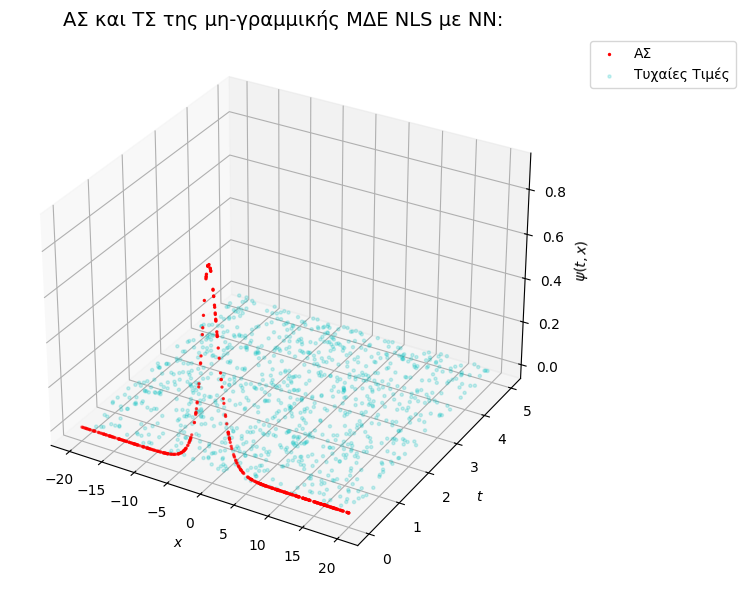

In [393]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

psi0_abs = torch.sqrt(u_0**2 + v_0**2) #μέτρο κυματοσυνάρτησης

#Αρχική Συνθήκη
ax.scatter(x_0.detach().cpu().numpy(), t_0.detach().cpu().numpy(), psi0_abs.detach().cpu().numpy(), color='r', label='ΑΣ', s=2);

#σημεία τυχαία
ax.scatter(x_r.cpu().detach(), t_r.cpu().detach(), c='c', marker='.', alpha=0.2, label='Τυχαίες Τιμές')

ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$ψ(t,x)$')
ax.set_title(r'ΑΣ και ΤΣ της μη-γραμμικής ΜΔΕ NLS με NN:', fontsize=14);
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [394]:
#Δημιουργία ΝΝ

class NeuralNetwork(nn.Module):
    def __init__(self, num_hidden_layers=8, num_neurons_per_layer=20):
        super(NeuralNetwork, self).__init__()

        #Το input layer συνδέεται στο 1ο layer (με 20 νευρώνες)
        self.input_layer = nn.Linear(2, num_neurons_per_layer)

        #Τα layers από το 1ο μέχρι το 8ο
        self.hidden_layers = nn.ModuleList([
            nn.Linear(num_neurons_per_layer,num_neurons_per_layer)

            for _ in range(num_hidden_layers)
        ])

        #Το output layer δίνει 2 τιμές: u και v
        self.output_layer = nn.Linear(num_neurons_per_layer, 2)

        #Αρχικοποίηση βαρών
        self._initialize_weights()

    def _initialize_weights(self):
       for layer in self.hidden_layers:
            #αποτρέπει τα πολύ μεγάλα και πολύ μικρά βάρη
            nn.init.xavier_normal_(layer.weight)

    def forward(self, x):
        #Μετασχηματιμσός του x για να βρίσκεται στο [lb[1], ub[1]]=[xmin,xmax]=[-1,1] για ταχύτερη επκπαίδευση με την tanh
        x = 2.0*(x - lb)/(ub - lb) - 1.0

        #Το input layer
        x = torch.tanh(self.input_layer(x))

        #1ο με 8ο hidden layer
        for layer in self.hidden_layers:
            x = torch.tanh(layer(x)) #+ 0.1 * x #skip connection ή residual connection

        #Το output layer
        x = self.output_layer(x)
        u = x[:, 0:1]  # πραγματικό μέρος
        v = x[:, 1:2]  # φανταστικό μέρος

        return u, v

In [395]:
#Υπολογισμός Απώλειας

mse_loss = nn.MSELoss() #Μέσο Τετραγωνικό Σφάλμα

def compute_loss(model, X_r, X_data, psi_data, epoch, verbose_flag):

    ##Απώλεια ΜΔΕ
    #Σπάσιμο στηλών t,x για να υπολογιστούν ξεχωριστά οι μερικές παράγωγοι
    t, x = X_r[:,0:1].detach().requires_grad_(True), \
           X_r[:,1:2].detach().requires_grad_(True)

    #Εκτίμηση ΜΔΕ μοντέλου
    u, v = model(torch.concat([t,x],dim=1)) #u = psi_re, v = psi_im

    #Υπολογισμός Μερικών Παραγώγων Πραγματικού και Φανταστικού Μέρους
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]
    v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]


    #Υπολογισμός του απώλειας της ΜΔΕ
    f_u, f_v = fun_r(u, v, u_t, v_t, u_xx, v_xx)
    l_u = torch.mean(torch.square(f_u))
    l_v = torch.mean(torch.square(f_v))
    l_psi = l_u + l_v

    ##Απώλεια αρχικής συνθήκης
    #Σπάσιμο του t0,x0 για να υπολογιστεί ξεχωριστά η μερική παράγωγος
    t0, x0 = X_data[0][:,0:1].detach().requires_grad_(True), \
             X_data[0][:,1:2].detach().requires_grad_(True)

    #Εκτίμηση μοντέλου για την θέση και ταχύτητα
    u0, v0 = model(torch.concat([t0, x0],dim=1))

    #Υπολογισμός απώλειας θέσης και ταχύτητας
    l_u0 = torch.mean(torch.square(psi_data[0]-u0))
    l_v0 = torch.mean(torch.square(psi_data[1]-v0))
    l_0 = l_u0 + l_v0


    ##Απώλεια συνοριακών τιμών (Περιοδικές)
    #Σπάσιμο στηλών t,xl,xr για να υπολογιστούν ξεχωριστά οι μερικές παράγωγοι
    tb, xbl, xbr = X_data[1][:,0:1].detach().requires_grad_(True), \
                   X_data[1][:,1:2].detach().requires_grad_(True), \
                   X_data[1][:,2:3].detach().requires_grad_(True)

    #Εκτίμηση μοντέλου Αριστερά μαζί με παραγώγους
    ubl, vbl = model(torch.concat([tb, xbl],dim=1))
    ubl_x = torch.autograd.grad(ubl, xbl, grad_outputs=torch.ones_like(ubl), create_graph=True, allow_unused=True)[0]
    vbl_x = torch.autograd.grad(vbl, xbl, grad_outputs=torch.ones_like(ubl), create_graph=True, allow_unused=True)[0]

    #Εκτίμηση μοντέλου Δεξιά
    ubr, vbr = model(torch.concat([tb, xbr],dim=1))
    ubr_x = torch.autograd.grad(ubr, xbr, grad_outputs=torch.ones_like(ubr), create_graph=True, allow_unused=True)[0]
    vbr_x = torch.autograd.grad(vbr, xbr, grad_outputs=torch.ones_like(ubr), create_graph=True, allow_unused=True)[0]

    #Υπολογισμός απώλειας συνοριακών συνθηκών
    l_u_lr = mse_loss(ubl, ubr)
    l_u_x_lr = mse_loss(ubl_x, ubr_x)
    l_v_lr = mse_loss(vbl, vbr)
    l_v_x_lr = mse_loss(vbl_x, vbr_x)
    l_b = l_u_lr + l_v_lr + l_u_x_lr + l_v_x_lr

    #Προσαρμογή Βαρών κάθε loss
    w_psi = 100
    w_b = 1
    w_0 = 10

    #Συνολική απώλεια
    loss = w_psi * l_psi + w_b * l_b + w_0 * l_0

    if (epoch % 100 == 0) and (verbose_flag != -1):
      print(f'Epoch {epoch:05d}: l_psi = {l_psi:10.8e}, l_b = {l_b:10.8e}, l_0 = {l_0:10.8e}, loss = {loss:10.8e}')
      #print(f'Epoch {epoch:05d}: w_psi = {w_psi:.2f}, w_b = {w_b:.2f}, w_0 = {w_0:.2f}')

    return loss

In [396]:
model = NeuralNetwork().to(device)

#Σταθερά learning rate
lr_schedule = [1e-3, 1e-4, 1e-5]
def get_lr(epoch):
    if epoch < 1000:
        return lr_schedule[0]
    elif epoch < 3000:
        return lr_schedule[1]
    else:
        return lr_schedule[2]

#Adam βελτιστοποιητής
optimizer = optim.Adam(model.parameters(), lr=lr_schedule[0])

In [397]:
#Αριθμός εποχών
epoch = 2000

#Λίστα απώλειας κάθε εποχής
losses = []

#Καταγραφή χρόνου (σε δευτερόλεπτα)
sec = time()

for i in range(epoch + 1):

    #Ενημέρωση της σταθεράς learning rate
    for param_group in optimizer.param_groups:
        param_group["lr"] = get_lr(i)

    #Μηδενισμός των παραγώγων του βελτιστοποιητή πριν το backpropagation
    optimizer.zero_grad()

    #Υπολογισμός σφάλματος
    loss = compute_loss(model, X_r, X_data, psi_data, i, verbose_flag=1)

    #Υπολογισμός των παραγώγων τρέχουσας εποχής
    loss.backward(retain_graph=True)

    #Ενημέρωση βαρών επόμενης εποχής
    optimizer.step()

    #Αποθήκευση του σφάλματος κάθε εποχής
    losses.append(loss.item())

    #Εφαρμογή του early stopping
    if loss.item() < 1e-5:
       break

#Εμφάνιση χρόνου εκτέλεσης του μοντέλου
seconds = time() - sec
days = seconds // (24*60*60)
hours = (seconds % (24*60*60)) // (60*60)
minutes = (seconds % (60*60)) // 60
second = int(seconds % 60)
print(f'\nΧρόνος Εκπαίδευσης Μοντέλου: {int(days)} μέρες, {int(hours)} ώρες, {int(minutes)} λεπτά, {int(second)} δευτερόλεπτα')
print(f'\nEpochs: {i}, loss = {losses[i]:10.8e}')


Epoch 00000: l_psi = 2.56576631e-02, l_b = 1.80208255e-02, l_0 = 7.75675923e-02, loss = 3.35946321e+00
Epoch 00100: l_psi = 9.71083646e-05, l_b = 6.37956036e-05, l_0 = 4.25787754e-02, loss = 4.35562372e-01
Epoch 00200: l_psi = 1.01761427e-04, l_b = 4.46522899e-05, l_0 = 4.23679426e-02, loss = 4.33900207e-01
Epoch 00300: l_psi = 1.08434520e-04, l_b = 4.09451786e-05, l_0 = 4.21876647e-02, loss = 4.32761043e-01
Epoch 00400: l_psi = 1.16385301e-04, l_b = 3.74821757e-05, l_0 = 4.19764370e-02, loss = 4.31440383e-01
Epoch 00500: l_psi = 1.26699539e-04, l_b = 2.70637975e-05, l_0 = 4.16866019e-02, loss = 4.29563016e-01
Epoch 00600: l_psi = 1.45650236e-04, l_b = 2.62705671e-05, l_0 = 4.11859006e-02, loss = 4.26450312e-01
Epoch 00700: l_psi = 2.00169539e-04, l_b = 8.10125202e-05, l_0 = 4.02147248e-02, loss = 4.22245204e-01
Epoch 00800: l_psi = 2.28973659e-04, l_b = 1.11849549e-04, l_0 = 3.94806117e-02, loss = 4.17815328e-01
Epoch 00900: l_psi = 2.80010310e-04, l_b = 3.14542849e-05, l_0 = 3.830822

In [398]:
# Fine-tuning με L-BFGS
#Καταγραφή χρόνου (σε δευτερόλεπτα)
sec = time()


lbfgs_counter = 0  #μετρητής βημάτων LBFGS

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(),    #μεταβολή των βαρών του μοντέλου
                                    max_iter=500,          #μέγιστος αριθμός εσωτερικών βημάτων
                                    tolerance_grad=1e-7,   #έξοδος όταν η μέση κλίση είναι μικρότερη από
                                    tolerance_change=1e-9, #έξοδος όταν τα βάρη είναι μικρότερα από
                                    history_size=20,       #πόσα προηγούμενα βήματα να θυμάται για την εκτίμηση της Hessian
                                    line_search_fn="strong_wolfe") #για σταθερή σύγκλιση, αποφυγεί πολύ μικρών/μεγάλων βημάτων

def closure():
    optimizer_lbfgs.zero_grad() #μηδενισμός προηγούμενων gradients
    loss = compute_loss(model, X_r, X_data, psi_data, 0, verbose_flag=-1) #υπολογισμός απώλειας
    loss.backward(retain_graph=True) #υπολογισμός gradients
    global lbfgs_counter #για να την πάρει από έξω
    lbfgs_counter = lbfgs_counter + 1 #μετρητής βημάτων LBFGS
    return loss

#Μία κλήση LBFGS (κάνει εσωτερικά 500 αλληλεπιδράσεις)
optimizer_lbfgs.step(closure)

# Τελική αξιολόγηση μετά το LBFGS
loss_lbfgs = compute_loss(model, X_r, X_data, psi_data, 0, verbose_flag=-1)

print(f"LBFGS Επανάληψη {lbfgs_counter}")
print(f"LBFGS Σφάλμα {loss_lbfgs.item():10.8e}")
print(f"LBFGS βελτίωση: Από {losses[-1]:.3e} σε {loss_lbfgs.item():.3e}")
print(f"Διαφορά LBFGS με Adam: {(loss_lbfgs.item() - losses[-1]):+10.8e}")

#Εμφάνιση χρόνου εκτέλεσης του LBFGS
seconds = time() - sec
days = seconds // (24*60*60)
hours = (seconds % (24*60*60)) // (60*60)
minutes = (seconds % (60*60)) // 60
second = int(seconds % 60)
print(f'\nΧρόνος Βελτιστοποίησης με LBFGS: {int(days)} μέρες, {int(hours)} ώρες, {int(minutes)} λεπτά, {int(second)} δευτερόλεπτα')


LBFGS Επανάληψη 538
LBFGS Σφάλμα 3.05058956e-01
LBFGS βελτίωση: Από 3.753e-01 σε 3.051e-01
Διαφορά LBFGS με Adam: -7.02577829e-02

Χρόνος Βελτιστοποίησης με LBFGS: 0 μέρες, 0 ώρες, 0 λεπτά, 18 δευτερόλεπτα


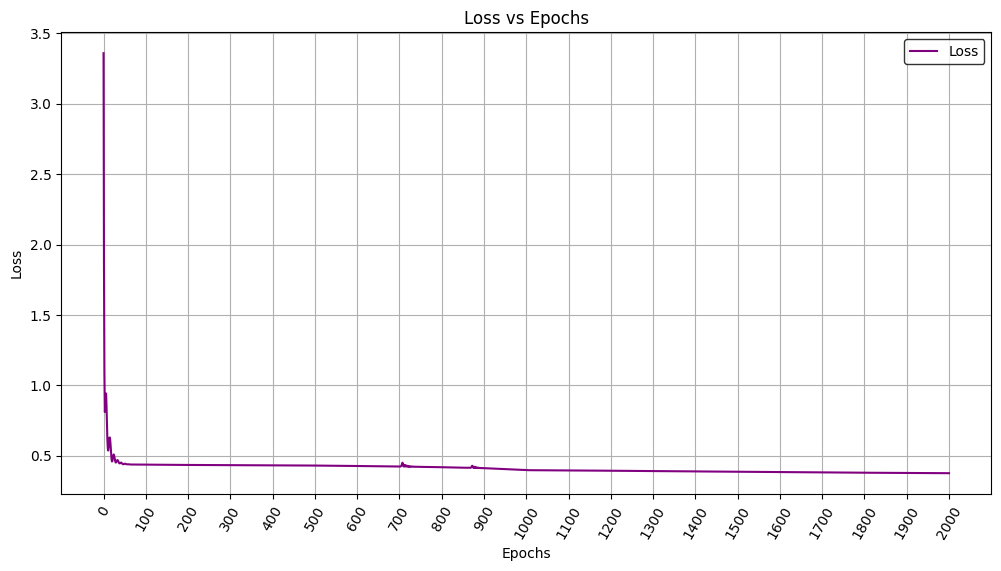

In [399]:
#Απώλεια κάθε εποχής
fig = plt.figure(figsize=(12,6))

plt.plot(range(len(losses)), losses, label="Loss", color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend(loc='upper right').get_frame().set_edgecolor('black')
plt.xticks(range(0, epoch+1, 100), rotation=60)
plt.grid(True)
plt.show()

u0_m:  torch.Size([500, 1])
v0_m:  torch.Size([500, 1])
A0_abs_m:  torch.Size([500, 1])
ubl_m:  torch.Size([700, 1])
vbl_m:  torch.Size([700, 1])
Abl_abs_m:  torch.Size([700, 1])
ubr_m:  torch.Size([700, 1])
vbr_m:  torch.Size([700, 1])
Abr_abs_m:  torch.Size([700, 1])


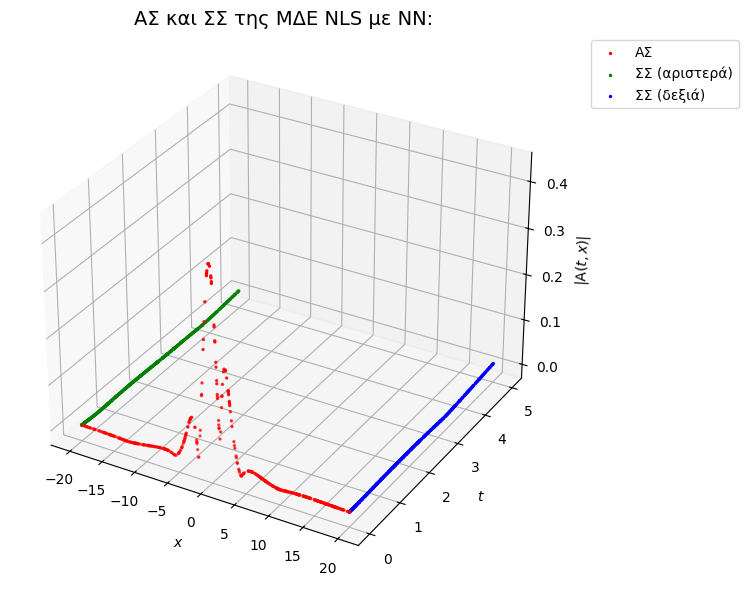

In [400]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')

#Τελική εκτίμηση μοντέλου Αρχικής Συνθήκης
u0_m, v0_m = model(torch.concat([t_0, x_0],dim=1))
A0_abs_m = torch.sqrt(u0_m**2 + v0_m**2)
print(f'u0_m: ',u0_m.shape)
print(f'v0_m: ',v0_m.shape)
print(f'A0_abs_m: ',A0_abs_m.shape)

#Τελική εκτίμηση μοντέλου Συνοριακής Συνθήκης Αριστερά
ubl_m, vbl_m = model(torch.concat([t_b, x_b_left],dim=1))
Abl_abs_m = torch.sqrt(ubl_m**2 + vbl_m**2)
print(f'ubl_m: ',ubl_m.shape)
print(f'vbl_m: ',vbl_m.shape)
print(f'Abl_abs_m: ',Abl_abs_m.shape)

#Τελική εκτίμηση μοντέλου Συνοριακής Συνθήκης Δεξιά
ubr_m, vbr_m = model(torch.concat([t_b, x_b_right],dim=1))
Abr_abs_m = torch.sqrt(ubr_m**2 + vbr_m**2)
print(f'ubr_m: ',ubr_m.shape)
print(f'vbr_m: ',vbr_m.shape)
print(f'Abr_abs_m: ',Abr_abs_m.shape)


#Αρχική Συνθήκη
ax.scatter(x_0.detach().cpu().numpy(), t_0.detach().cpu().numpy(), A0_abs_m.detach().cpu().numpy(), color='r', label='ΑΣ', s=2);

#Συνοριακή Συνθήκη (Αριστερά)
ax.scatter(x_b_left.detach().cpu().numpy(), t_b.detach().cpu().numpy(), Abl_abs_m.detach().cpu().numpy(), color='g', label='ΣΣ (αριστερά)', s=2);

#Συνοριακή Συνθήκη (Δεξιά)
ax.scatter(x_b_right.detach().cpu().numpy(), t_b.detach().cpu().numpy(), Abr_abs_m.detach().cpu().numpy(), color='b', label='ΣΣ (δεξιά)', s=2);


ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$|Α(t,x)|$')
ax.set_title(r'ΑΣ και ΣΣ της ΜΔΕ NLS με NN:', fontsize=14);
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

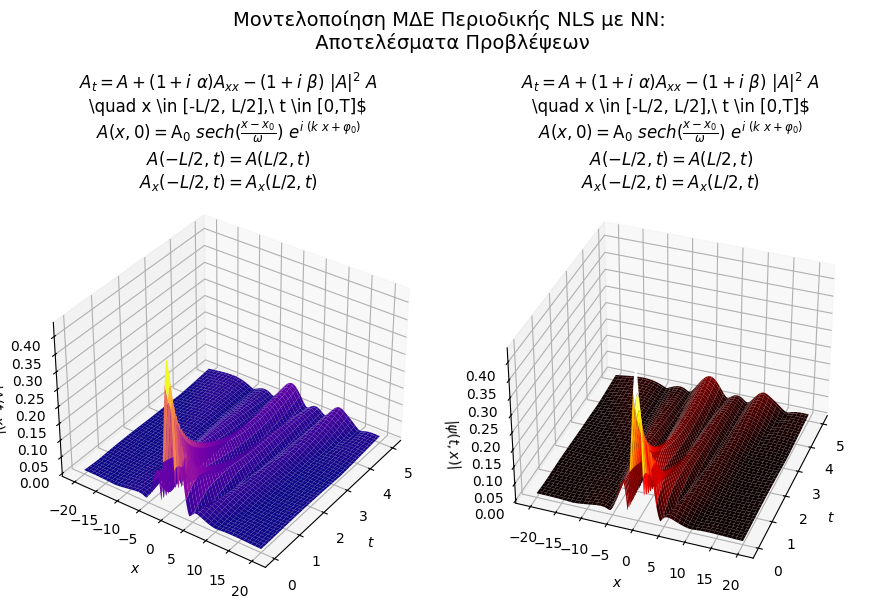

Για t=[0,T] έχουμε min |A| = 0.000, max |A| = 0.430
Στο t=Τ έχουμε min |A| = 0.001, max |A| = 0.066


In [401]:
from mpl_toolkits.mplot3d import Axes3D #βιβλιοθήκη για 3D γραφήματα

#Πλήθος διαστημάτων
N = 1000

#Δημιουργία σημείων
tspace = np.linspace(tmin, tmax, N + 1) #(N+1,1)
xspace = np.linspace(xmin, xmax, N + 1) #(N+1,1)

#Δημιουργία πλέγματος σημείων
T, X = np.meshgrid(tspace, xspace) #(N+1,N+1) , (N+1,N+1)

#κάθε γραμμή ένα σημείο του πλέγματος
Xgrid = np.vstack([T.flatten(),X.flatten()]).T #((Ν+1)^2,2)

#Υπολογίζει τις προβλέψεις u(t, x) του μοντέλου
u_pred, v_pred = model(torch.tensor(Xgrid,dtype=dtype).to(device)) #((Ν+1)^2,1)

#Από ((Ν+1)^2,1) σε (Ν+1,Ν+1)
U = u_pred.cpu().detach().numpy().reshape(N+1,N+1)
V = v_pred.cpu().detach().numpy().reshape(N+1,N+1)
A_abs = np.sqrt(U**2 + V**2)

#Γράφημα πρόβλεψης u(t,x) από δύο οπτικές γωνίες
fig = plt.figure(figsize=(9,6))
fig.suptitle('Μοντελοποίηση ΜΔΕ Περιοδικής NLS με NN:\n Αποτελέσματα Προβλέψεων', fontsize=14)

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T, X, A_abs, cmap='plasma');
ax1.view_init(35,35)
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_zlabel('$|A(t,x)|$')
ax1.set_title(r'$A_t = A + (1+i\ α) A_{xx} - (1+i\ β)\ |A|^2\ A$' '\n'
              r'\quad x \in [-L/2, L/2],\ t \in [0,T]$' '\n'
              r'$A(x,0) = Α_0\ sech( \frac{x - x_0}{ω})\ e^{i\ (k\ x + φ_0)}$' '\n'
              r'$A(-L/2, t) = A(L/2, t)$' '\n'
              r'$A_x(-L/2, t) = A_x(L/2, t) $',
              fontsize=12);
ax1.invert_xaxis()


ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(T, X, A_abs, cmap='hot');
ax2.view_init(35,20)
ax2.set_xlabel('$t$')
ax2.set_ylabel('$x$')
ax2.set_zlabel('$|ψ(t,x)|$')
ax2.set_title(r'$A_t = A + (1+i\ α) A_{xx} - (1+i\ β)\ |A|^2\ A$' '\n'
              r'\quad x \in [-L/2, L/2],\ t \in [0,T]$' '\n'
              r'$A(x,0) = Α_0\ sech( \frac{x - x_0}{ω})\ e^{i\ (k\ x + φ_0)}$' '\n'
              r'$A(-L/2, t) = A(L/2, t)$' '\n'
              r'$A_x(-L/2, t) = A_x(L/2, t) $',
              fontsize=12);
ax2.invert_xaxis()

# Εμφάνιση του αποτελέσματος
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

print(f'Για t=[0,T] έχουμε min |A| = {A_abs.min():.3f}, max |A| = {A_abs.max():.3f}')

# Τελικό χρονικό βήμα
A_final = A_abs[:,-1]  # τελευταία γραμμή

# Μέγιστο πλάτος στο t_max
A_min = np.min(A_final)
A_max = np.max(A_final)
print(f'Στο t=Τ έχουμε min |A| = {A_min:.3f}, max |A| = {A_max:.3f}')